# Eigenfaces: PCA you can watch

### ECE 8803-AI4 · Module: Fault Detection and Classification
### Supplementary Lecture — *Thirty Faces, Fifteen Numbers*

**Asif Khan** · School of Electrical and Computer Engineering / School of Materials Science and
Engineering · Georgia Institute of Technology · `akhan40@gatech.edu`
Course website: <https://aikhan123.github.io/khan-lab-website/ai-semiconductors-course.html>

---

This notebook regenerates **every figure and every number** in the accompanying slide deck.
Nothing below is precomputed, hardcoded or copied off a slide: the percentages, the
coefficients, the reconstruction errors and the singular values are all read out of the same
PCA that draws the pictures. If you change the thirty faces, every downstream number follows.

### Why faces, in a fault-detection course

The FDC lecture builds a baseline from a hundred healthy process runs, keeps three
*eigentraces*, and scores a new run by how far it sits from that baseline. That is exactly the
machinery below, with one substitution:

| Fault detection lecture | This notebook |
|---|---|
| one process run, 200 samples long | one photograph, 16,384 pixels |
| 100 healthy runs | 30 portraits |
| the mean run (the "golden trace") | the average face |
| eigentraces E1, E2, E3 | eigenfaces E1 … E29 |
| a run's 3 coefficients | a face's 15 amounts |
| residual after projection | reconstruction error |
| SPE — the part the model could not explain | what is left of a cat after you rebuild it from faces |

Faces are used here only because *you* can see the residual. Your eye is a far better judge of
"the model failed to explain this" on a face than on a chamber-pressure trace, so every failure
mode of the method announces itself. Everything transfers back unchanged.

### How to use it

Run the cells in order; each section corresponds to a run of slides. The exercises at the end
are the point — they are where the method breaks, and where you learn what it is actually doing.

**Requirements.** `numpy`, `matplotlib`, `pillow`. **No network needed** — the thirty portraits
ship with the notebook in `faces_30.npz` (0.4 MB), which must sit in the same folder. If that
file is missing the notebook downloads the portraits instead, and if there is no network either
it falls back to the Olivetti face database bundled with scikit-learn; every lesson still holds,
only the specific numbers change.

**Files.** `ECE8803-AI4_Lecture-2S_Eigenfaces.ipynb` and `faces_30.npz`, in one folder. That is
all. The notebook writes `stats_notebook.json` when you run it, and `figs/` if you switch
figure saving on.

**Runtime.** About a minute end to end on a laptop. No GPU, no training, no fitting loop —
PCA is one call to `numpy.linalg.svd`.

---
## 0 · Setup

The palette is the Georgia Tech deck palette, so figures you produce here drop straight into
slides. `FIGS` controls whether figures are also written to disk as PNGs.

In [1]:
import io, json, os, urllib.request, warnings
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

warnings.filterwarnings("ignore", category=UserWarning)

# ---- Georgia Tech palette (same values the deck uses) ----------------------
NAVY  = "#003057"   # titles, primary text
GREY  = "#545859"   # body copy, captions
TEAL  = "#008C95"   # primary accent
GOLD  = "#A87900"   # secondary accent
RULE  = "#D6DBD3"   # hairlines
CARD  = "#EDF1F4"   # panel fill

mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "savefig.bbox": "tight",
    "figure.dpi": 110, "savefig.dpi": 150,
    "text.color": NAVY, "axes.labelcolor": GREY,
    "xtick.color": GREY, "ytick.color": GREY,
    "axes.edgecolor": "#C9D2D9", "grid.color": "#E3E8EB",
    "font.size": 11, "axes.titlesize": 12, "axes.titlecolor": NAVY,
    "legend.frameon": False, "axes.spines.top": False, "axes.spines.right": False,
})

FIGS = None                     # set to a folder name, e.g. "figs", to also save PNGs
def savefig(name):
    if FIGS:
        os.makedirs(FIGS, exist_ok=True)
        plt.savefig(f"{FIGS}/{name}.png")

rng = np.random.default_rng(7)  # fixed seed: the notebook reproduces exactly

S = 128                         # every face is resized to S x S
D = S * S                       # so one photograph is D numbers
N = 30                          # how many faces we use

print(f"one photograph = {S} x {S} = {D:,} numbers")
print(f"the data set   = {N} photographs = {N*D:,} numbers in total")

one photograph = 128 x 128 = 16,384 numbers
the data set   = 30 photographs = 491,520 numbers in total


---
## 1 · Get the faces

Thirty portraits from **Flickr-Faces-HQ** (FFHQ, NVIDIA), licence CC BY-NC-SA 4.0 — fine for
classroom teaching, not for commercial use. They were chosen by eye from a contact sheet of the
first 300 for frontal pose, clean lighting, no occlusion, and a spread of age, gender and
ethnicity.

The cell below tries three sources, in order, and tells you which one it used:

1. **`faces_30.npz` sitting next to this notebook** — the thirty portraits, already cropped and
   greyscaled, shipped with the notebook. No network needed. This is the normal path.
2. **Download from the Hugging Face datasets server** into `./ffhq/`, if the bundle is missing.
3. **Olivetti faces** from scikit-learn, if there is also no network. Every lesson still holds;
   only the specific numbers change.

Paths 1 and 2 produce **bit-identical** arrays — the bundle stores the same `uint8` values the
download path would produce, so the notebook's numbers do not depend on which one ran.

Each portrait is cropped to the face, converted to greyscale and resized to 128 × 128, then
**unrolled row by row into a single vector of 16,384 numbers**. That unrolling is worth
pausing on: it throws away the fact that pixels have neighbours. PCA never learns the picture
was two-dimensional, and would return identical answers if you shuffled all 16,384 pixel
positions — provided you shuffled every photograph the same way.

Scaling to `[0, 1]` rather than `[0, 255]` is cosmetic; it only sets the units the errors are
reported in.

In [2]:
PICKS = ["0001","0006","0012","0018","0019","0040","0043","0047","0055","0056",
         "0059","0064","0065","0066","0067","0073","0075","0076","0081","0082",
         "0087","0091","0093","0103","0110","0113","0114","0115","0116","0119"]

FFHQ = "ffhq"
API  = ("https://datasets-server.huggingface.co/rows"
        "?dataset=bitmind%2Fffhq-256&config=default&split=train&offset={}&length=100")


def fetch_ffhq(picks, timeout=60):
    """Download just the portraits we need, caching them in ./ffhq/."""
    os.makedirs(FFHQ, exist_ok=True)
    want = {int(p) for p in picks}
    missing = [p for p in picks if not os.path.exists(f"{FFHQ}/{p}.jpg")]
    if not missing:
        return True
    rows = []
    for off in range(0, max(want) + 100, 100):
        with urllib.request.urlopen(API.format(off), timeout=timeout) as r:
            rows += json.load(r)["rows"]
    todo = [(r["row_idx"], r["row"]["image"]["src"]) for r in rows if r["row_idx"] in want]

    def get(item):
        i, src = item
        path = f"{FFHQ}/{i:04d}.jpg"
        if not os.path.exists(path):
            urllib.request.urlretrieve(src, path)

    with ThreadPoolExecutor(16) as ex:
        list(ex.map(get, todo))
    return all(os.path.exists(f"{FFHQ}/{p}.jpg") for p in picks)


def load_portrait(tag):
    """Greyscale, crop to the face, resize to S x S, scale to [0, 1], unroll."""
    im = Image.open(f"{FFHQ}/{tag}.jpg").convert("L")
    W, H = im.size
    im = im.crop((int(.20 * W), int(.13 * H), int(.80 * W), int(.85 * H)))
    return np.asarray(im.resize((S, S), Image.LANCZOS), dtype=np.float64).ravel() / 255.


BUNDLE = "faces_30.npz"       # shipped alongside this notebook

faces, SOURCE = None, None

# ---- 1. the bundled portraits (no network) --------------------------------
if os.path.exists(BUNDLE):
    z = np.load(BUNDLE, allow_pickle=False)
    faces  = z["faces_u8"].astype(np.float64) / 255.     # exactly the download path
    S      = int(z["size"][0]); D = S * S; N = faces.shape[0]
    SOURCE = f'{z["source"][0]} (bundled)'
    print(f'licence: {z["licence"][0]}')

# ---- 2. otherwise fetch them ----------------------------------------------
if faces is None:
    try:
        ok = fetch_ffhq(PICKS)
    except Exception as exc:
        print("FFHQ download failed:", exc); ok = False
    if ok:
        faces, SOURCE = np.stack([load_portrait(t) for t in PICKS]), "FFHQ (downloaded)"

# ---- 3. offline fallback ---------------------------------------------------
if faces is None:
    from sklearn.datasets import fetch_olivetti_faces
    ol = fetch_olivetti_faces(shuffle=False)
    faces = np.stack([
        np.asarray(Image.fromarray((ol.images[i * 10] * 255).astype(np.uint8))
                   .resize((S, S), Image.LANCZOS), dtype=np.float64).ravel() / 255.
        for i in range(N)])
    SOURCE = "Olivetti (fallback)"
    print("Using the Olivetti fallback — the lesson holds, the numbers will differ.")

print(f"source: {SOURCE}")
print(f"faces:  {faces.shape}   -> {faces.shape[0]} rows, one per photograph;"
      f" {faces.shape[1]:,} columns, one per pixel")
print(f"range:  {faces.min():.2f} to {faces.max():.2f}")

licence: CC BY-NC-SA 4.0 - teaching use; attribution and share-alike required; not for commercial use
source: Flickr-Faces-HQ (FFHQ), NVIDIA (bundled)
faces:  (30, 16384)   -> 30 rows, one per photograph; 16,384 columns, one per pixel
range:  0.00 to 1.00


### Drawing helpers

`show()` draws one flattened vector as an image. The `signed=True` branch matters: eigenfaces
and difference maps contain **negative** numbers, and negative brightness does not exist. Those
are drawn on a symmetric scale where mid-grey means zero — which is the only honest way to put
them on screen, and the reason eigenfaces look like ghosts.

In [3]:
def show(vec, ax=None, title=None, signed=False, scale=None, tcolor=None, fs=10):
    """Draw one flattened image. signed=True centres mid-grey on zero."""
    ax = ax or plt.gca()
    img = np.asarray(vec).reshape(S, S)
    if signed:
        m = scale or (np.abs(img).max() or 1)
        ax.imshow(img, cmap="gray", vmin=-m, vmax=m)
    else:
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    if title:
        ax.set_title(title, fontsize=fs, color=tcolor or GREY, pad=4)
    return ax


def grid(vectors, titles=None, cols=10, w=1.15, signed=False, scale=None,
         tcolor=None, fs=8.5, suptitle=None):
    """A contact sheet of many faces."""
    n = len(vectors)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * w, rows * (w + 0.22)))
    axes = np.atleast_1d(axes).ravel()
    for k, ax in enumerate(axes):
        if k < n:
            show(vectors[k], ax, titles[k] if titles else None,
                 signed=signed, scale=scale, tcolor=tcolor, fs=fs)
        else:
            ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, color=NAVY, fontsize=12)
    fig.tight_layout()
    return fig


def mae(a, b):
    """Mean absolute error as a percentage of the 0-1 brightness range."""
    return 100 * np.abs(np.asarray(a) - np.asarray(b)).mean()

---
## 2 · Warm-up: two numbers per person

Before 16,384 dimensions, do it in two. Measure everyone's height and arm span. The dots form
a stretched-out sausage, because the two measurements are not independent — tall people have
long arms.

If you could keep only **one** number per person, you would keep neither height nor arm span.
You would keep the position *along* the sausage. That direction is component 1. The thin
direction across it barely varies, so throwing it away costs almost nothing.

Two measurements turned out to be one thing wearing two hats: bigness. That is the whole of PCA,
and everything after this is the same move in more dimensions.

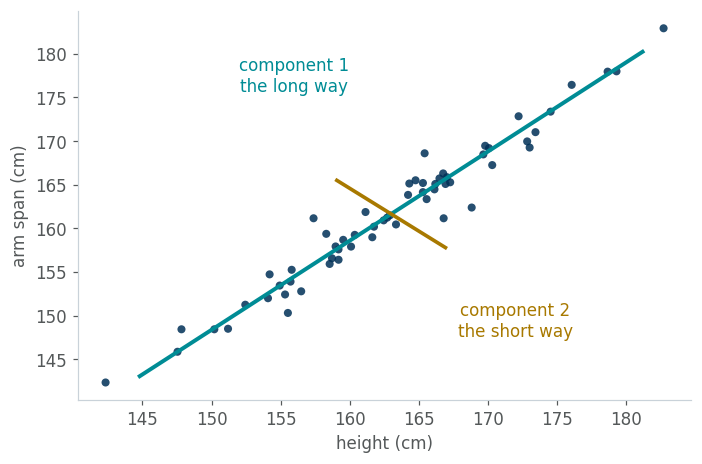

spread along component 1: 11.50 cm
spread along component 2:  1.23 cm
component 1 carries 98.9% of the variation


In [4]:
h_ = rng.normal(0, 1, 60)
height = 165 + 9.0 * h_ + rng.normal(0, 1.4, 60)
arm    = 164 + 9.4 * h_ + rng.normal(0, 1.6, 60)

pts = np.c_[height - height.mean(), arm - arm.mean()]
V   = np.linalg.svd(pts, full_matrices=False)[2]        # rows = the two directions

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.scatter(height, arm, s=28, color=NAVY, alpha=.85, edgecolors="none")
t = np.linspace(-26, 26, 2)
ax.plot(height.mean() + V[0, 0] * t, arm.mean() + V[0, 1] * t, color=TEAL, lw=2.6)
t2 = np.linspace(-5.5, 5.5, 2)
ax.plot(height.mean() + V[1, 0] * t2, arm.mean() + V[1, 1] * t2, color=GOLD, lw=2.4)
ax.text(height.mean() - 7, arm.mean() + 14, "component 1\nthe long way",
        color=TEAL, ha="center")
ax.text(height.mean() + 9, arm.mean() - 14, "component 2\nthe short way",
        color=GOLD, ha="center")
ax.set_xlabel("height (cm)"); ax.set_ylabel("arm span (cm)")
savefig("scatter"); plt.show()

spread = (pts @ V.T).std(0)
print(f"spread along component 1: {spread[0]:5.2f} cm")
print(f"spread along component 2: {spread[1]:5.2f} cm")
print(f"component 1 carries {100*spread[0]**2/(spread**2).sum():.1f}% of the variation")

---
## 3 · A photograph is already a list of numbers

Nothing has been done to the picture here. This is simply what an image *is*: a grid of
brightness values, 0 for black and 255 for white. Zoom in far enough and it was numbers all
along.

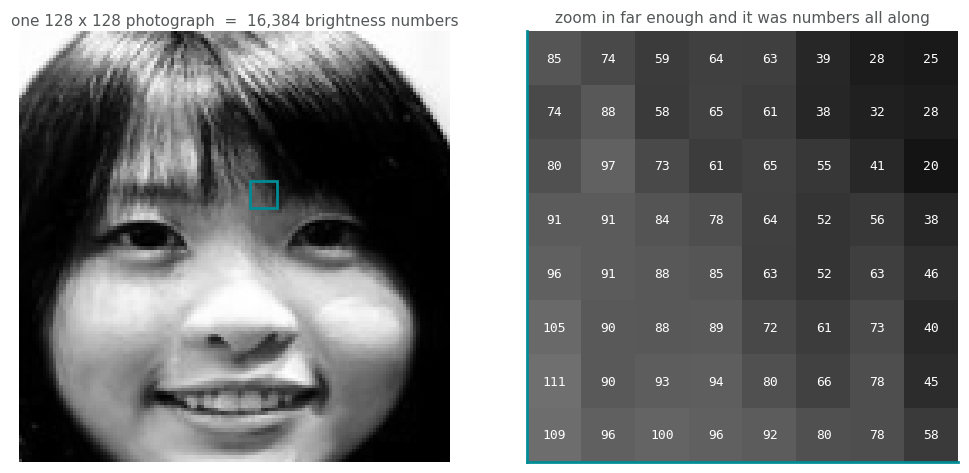

In [5]:
TGT = 8                                   # the face followed through the whole build-up
face = faces[TGT]
r0, c0 = 44, 68                           # a small patch to zoom into

fig, (a, b) = plt.subplots(1, 2, figsize=(9.4, 4.4))
show(face, a, f"one {S} x {S} photograph  =  {D:,} brightness numbers")
a.add_patch(plt.Rectangle((c0, r0), 8, 8, ec=TEAL, fc="none", lw=1.8))

patch = (face.reshape(S, S)[r0:r0 + 8, c0:c0 + 8] * 255).round().astype(int)
b.imshow(patch, cmap="gray", vmin=0, vmax=255)
for rr in range(8):
    for cc in range(8):
        v = patch[rr, cc]
        b.text(cc, rr, str(v), ha="center", va="center", fontsize=8.5,
               color="black" if v > 130 else "white", family="monospace")
b.set_xticks([]); b.set_yticks([])
for sp in b.spines.values():
    sp.set_color(TEAL); sp.set_linewidth(1.8)
b.set_title("zoom in far enough and it was numbers all along", fontsize=10, color=GREY)
fig.tight_layout(); savefig("pixels"); plt.show()

### Faces are a vanishingly thin sheet inside a huge space

A photograph is a single **point** in 16,384-dimensional space. Almost every point in that
space is static. Faces occupy a fantastically thin sheet inside it — and finding that sheet is
PCA's entire job.

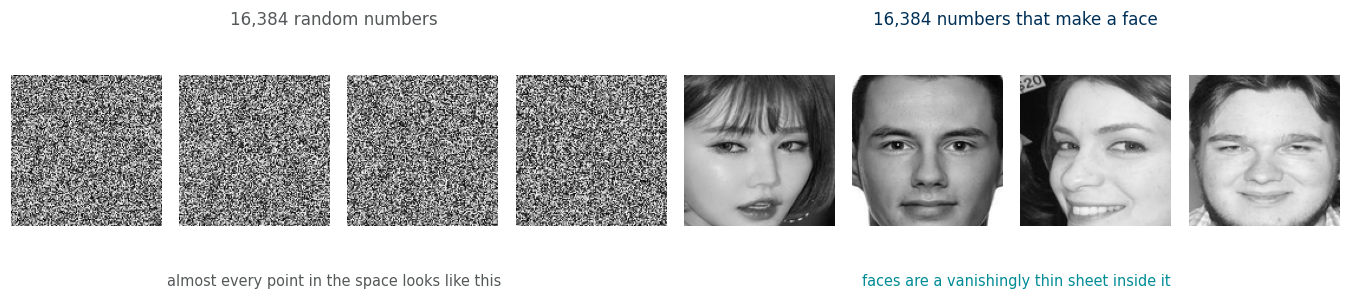

In [6]:
fig, axes = plt.subplots(1, 8, figsize=(12.4, 2.2))
for k in range(4):
    show(rng.random(D), axes[k])
for k, i in enumerate([6, 11, 21, 27]):
    show(faces[i], axes[4 + k])
fig.text(0.25, 1.02, f"{D:,} random numbers", ha="center", color=GREY)
fig.text(0.75, 1.02, f"{D:,} numbers that make a face", ha="center", color=NAVY)
fig.text(0.25, -0.06, "almost every point in the space looks like this",
         ha="center", color=GREY, fontsize=9.5)
fig.text(0.75, -0.06, "faces are a vanishingly thin sheet inside it",
         ha="center", color=TEAL, fontsize=9.5)
fig.tight_layout(); savefig("noise_vs_faces"); plt.show()

---
## 4 · Look at the data first. Always.

Note that the faces are **aligned** — eyes in roughly the same place in every frame. PCA has no
idea what a face is. Feed it unaligned pictures and it spends its first several components
describing wobble instead of people, exactly as the FDC lecture's detector wasted its
components on start-time variation until the traces were aligned. Alignment is not a
preprocessing detail; it is what decides whether the components mean anything.

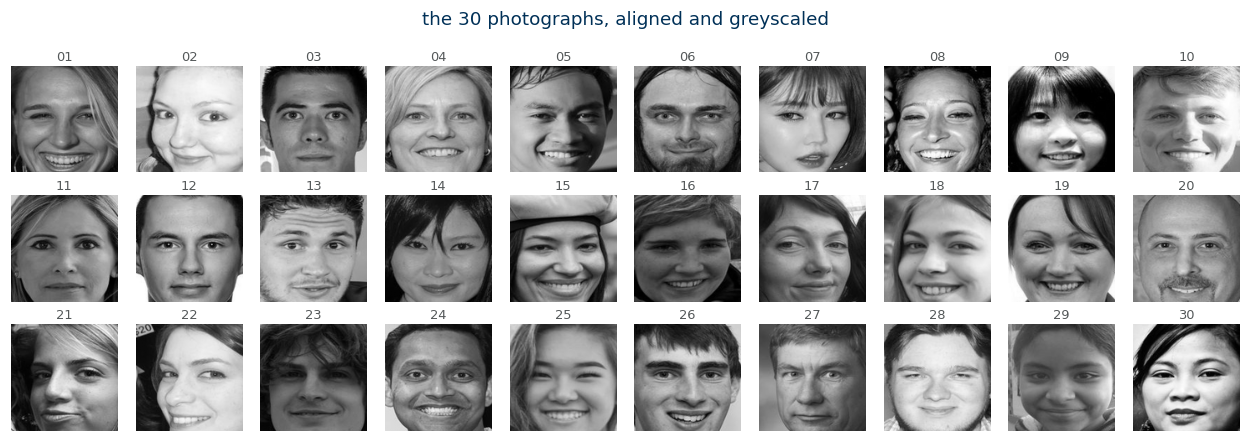

In [7]:
grid(faces, [f"{i+1:02d}" for i in range(N)], cols=10,
     suptitle=f"the {N} photographs, aligned and greyscaled")
savefig("contact_sheet"); plt.show()

---
## 5 · The average face, and what is left over

Add up all thirty pixel by pixel and divide by thirty. The result belongs to nobody: it is the
starting point from which every real face is described as a *departure*.

PCA never looks at the faces themselves. It looks at these **difference maps** — mid-grey means
"no different from average", lighter means brighter than average, darker means darker.

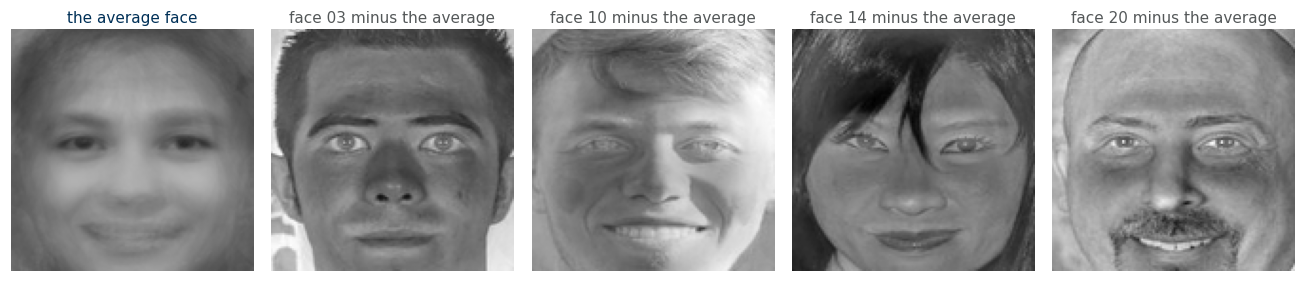

do the difference maps sum to zero?   max |column sum| = 1.15e-14


In [8]:
mean = faces.mean(axis=0)
A    = faces - mean                     # the difference maps: N x D, mean-centred

fig, axes = plt.subplots(1, 5, figsize=(12, 2.9))
show(mean, axes[0], "the average face", tcolor=NAVY)
for ax, i in zip(axes[1:], [2, 9, 13, 19]):
    show(A[i], ax, f"face {i+1:02d} minus the average", signed=True)
fig.tight_layout(); savefig("mean_face"); plt.show()

print("do the difference maps sum to zero?   max |column sum| = %.2e" % np.abs(A.sum(0)).max())

That check matters more than it looks. Once the mean is subtracted, the thirty difference maps
are **forced** to add up to zero. That is one linear constraint, and it costs exactly one
dimension — which is why thirty faces give twenty-nine eigenfaces and not thirty. We will see
the same 29 appear three more times below, from three different directions.

---
## 6 · The covariance matrix, and the trick nobody skips

The textbook object is

$$C \;=\; \tfrac{1}{N}\,A^{\mathsf T} A \qquad (16{,}384 \times 16{,}384)$$

— 268 million entries, and a rank of at most 29. Building it is not merely wasteful; on most
machines it is not possible. The Turk–Pentland trick is to work with the **Gram matrix**
instead,

$$G \;=\; \tfrac{1}{N}\,A A^{\mathsf T} \qquad (30 \times 30),$$

which has **identical non-zero eigenvalues**. Then map the eigenvectors back:

$$G\,v_i = \lambda_i v_i \quad\Longrightarrow\quad u_i = \frac{A^{\mathsf T} v_i}{\lVert A^{\mathsf T} v_i \rVert}.$$

$AA^{\mathsf T}$ and $A^{\mathsf T}A$ always share their non-zero eigenvalues, and
$A^{\mathsf T}A$ can have no more of them than $A$ has rows. That single fact is both the
computational shortcut and the reason the answer is 29.

Below, $C$ is drawn at 32 × 32 resolution so it fits on a screen — the real one would be
16,384 × 16,384. Teal off the diagonal means two pixels that brighten together; gold means one
brightens as the other dims.

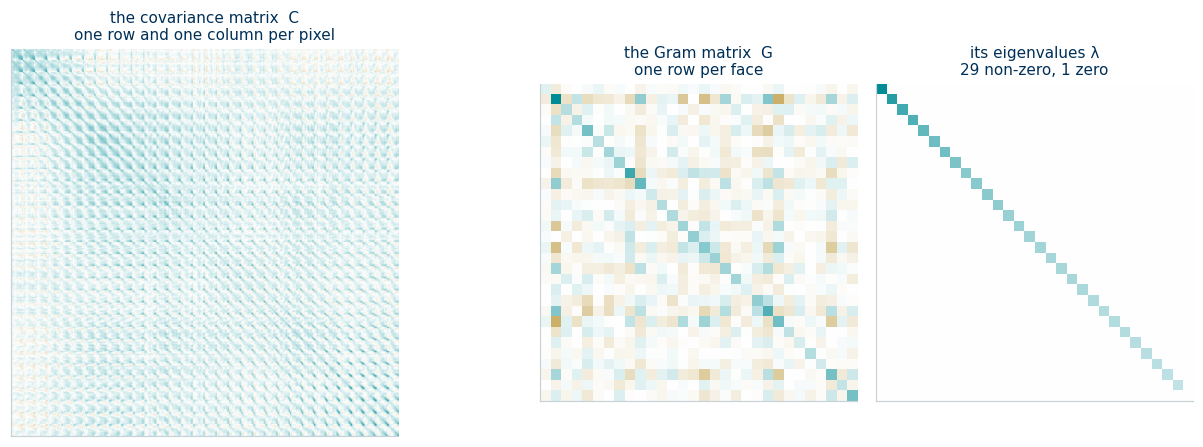

C is 1,024 x 1,024 = 1,048,576 entries, rank 29
G is 30 x 30 = 900 entries, rank 29
C is 1165x larger, and at full size 298,262x larger
largest 5 eigenvalues agree:  C [13.326191  7.583373  4.772741  3.682178  2.654204]
                              G [13.326191  7.583373  4.772741  3.682178  2.654204]


In [9]:
SM = 32
small = np.stack([
    np.asarray(Image.fromarray((f.reshape(S, S) * 255).astype(np.uint8))
               .resize((SM, SM), Image.LANCZOS), dtype=np.float64).ravel() / 255.
    for f in faces])
As = small - small.mean(0)
C_small = As.T @ As / N            # 1,024 x 1,024  (stand-in for 16,384 x 16,384)
G_small = As @ As.T / N            # 30 x 30

div = mpl.colors.LinearSegmentedColormap.from_list("gt", [GOLD, "white", TEAL])

fig, (a, b, c) = plt.subplots(1, 3, figsize=(12.2, 4.2),
                              gridspec_kw={"width_ratios": [3, 1.5, 1.5]})
for ax, M, t, s in [(a, C_small, "the covariance matrix  C\none row and one column per pixel", None),
                    (b, G_small, "the Gram matrix  G\none row per face", None),
                    (c, np.diag(np.clip(np.linalg.eigvalsh(G_small)[::-1], 0, None) ** .3),
                     "its eigenvalues λ\n29 non-zero, 1 zero", None)]:
    m = np.abs(M).max()
    ax.imshow(M, cmap=div, vmin=-m, vmax=m)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(t, fontsize=10, color=NAVY)
fig.tight_layout(); savefig("covmat"); plt.show()

evC = np.linalg.eigvalsh(C_small)[::-1]
evG = np.linalg.eigvalsh(G_small)[::-1]
print(f"C is {C_small.shape[0]:,} x {C_small.shape[1]:,} = {C_small.size:,} entries, rank {np.linalg.matrix_rank(C_small)}")
print(f"G is {G_small.shape[0]:,} x {G_small.shape[1]:,} = {G_small.size:,} entries, rank {np.linalg.matrix_rank(G_small)}")
print(f"C is {C_small.size / G_small.size:.0f}x larger, and at full size {(D**2) / (N**2):,.0f}x larger")
print("largest 5 eigenvalues agree:  C %s\n                              G %s"
      % (np.round(evC[:5], 6), np.round(evG[:5], 6)))

---
## 7 · The eigenfaces

One call does it. `full_matrices=False` is doing real work: it returns 30 right singular
vectors instead of attempting 16,384. That **is** the Gram trick, in disguise — which is why
you will never see a working eigenface implementation that forms $C$ explicitly.

$$A = U \Sigma V^{\mathsf T}, \qquad
\text{eigenfaces} = \text{rows of } V^{\mathsf T}, \qquad
\lambda_i = \frac{\sigma_i^2}{N}.$$

The sign fix on the next line is not cosmetic. The SVD leaves each component's sign arbitrary,
so without pinning it, "add more of E1" points in a direction that flips unpredictably between
runs and every morphing figure reverses.

orthonormal?  E1.E1 = 1.000000   E1.E2 = 5.20e-16
variance share of the first ten: [27.4 15.7 10.   7.7  5.6  4.3  3.9  3.1  2.3  2.2]
cumulative:                      [27.4 43.1 53.1 60.8 66.4 70.7 74.7 77.8 80.1 82.3]


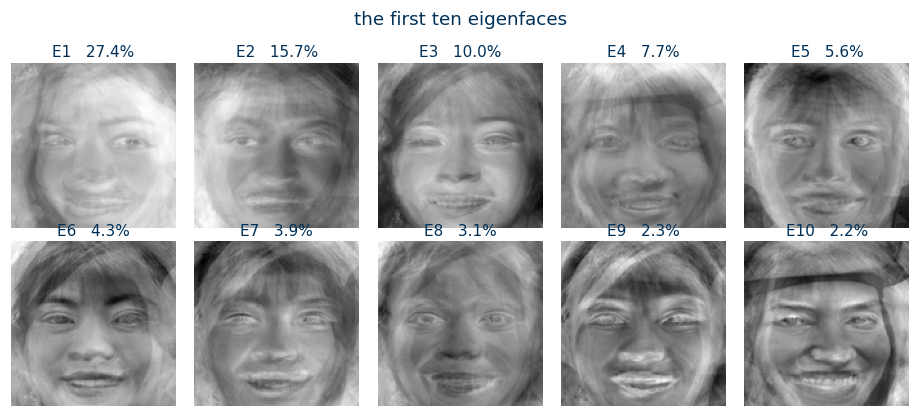

In [10]:
U_, sv, Vt = np.linalg.svd(A, full_matrices=False)

comps  = Vt.copy()                  # rows are eigenfaces, unit length, mutually orthogonal
evals  = sv ** 2 / N                # variance captured along each
coeffs = A @ comps.T                # every face's amounts: N x N

for j in range(len(comps)):         # pin the arbitrary sign: brighter side is positive
    if comps[j].sum() < 0:
        comps[j]     *= -1
        coeffs[:, j] *= -1

var_pct = 100 * evals / evals.sum()
cum     = np.cumsum(var_pct)
sd      = np.sqrt(np.maximum(evals, 0))

print("orthonormal?  E1.E1 = %.6f   E1.E2 = %.2e" %
      (comps[0] @ comps[0], comps[0] @ comps[1]))
print("variance share of the first ten:", np.round(var_pct[:10], 1))
print("cumulative:                     ", np.round(cum[:10], 1))

grid(comps[:10], [f"E{j+1}   {var_pct[j]:.1f}%" for j in range(10)],
     cols=5, w=1.7, signed=True, tcolor=NAVY, fs=10,
     suptitle="the first ten eigenfaces")
savefig("eigenfaces"); plt.show()

Half the numbers in an eigenface are **negative**, and negative brightness does not exist — so
an eigenface cannot be displayed as a real photograph. The images above are rescaled so that
mid-grey stands in for zero. Shown honestly on a 0–255 range, an eigenface would be a flat grey
square.

Read them as **directions of change**, not as people: E1 is roughly overall exposure and face
shape, E2 the frame of hair around the face, and by the twenties they are pure texture and edges.
Nobody told PCA what any of those mean — the axes fell out of the covariance structure alone.
Here is the full catalogue.

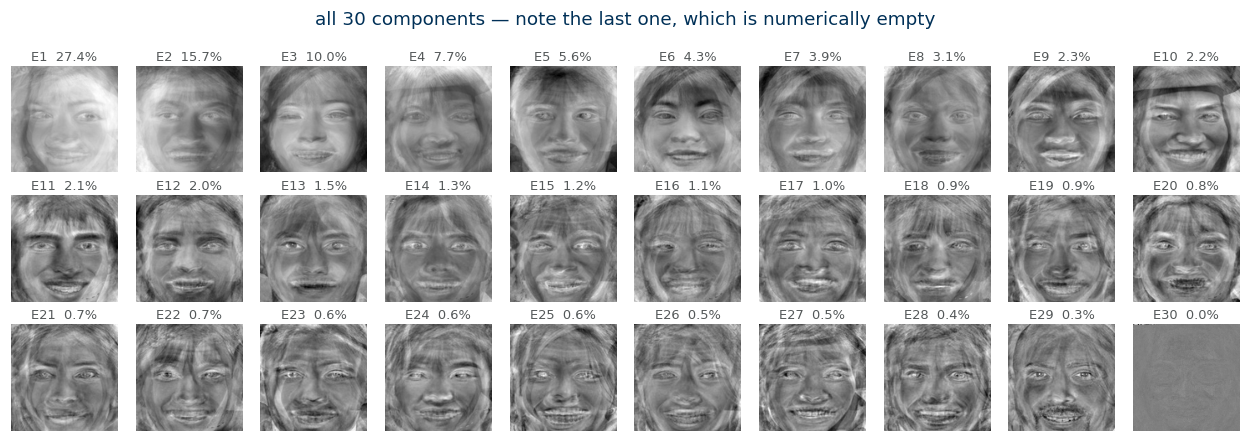

In [11]:
grid(comps, [f"E{j+1}  {var_pct[j]:.1f}%" for j in range(len(comps))],
     cols=10, w=1.15, signed=True,
     suptitle="all 30 components — note the last one, which is numerically empty")
savefig("eigenfaces_all"); plt.show()

---
## 8 · How many eigenvectors are there really?

Strictly, 16,384 — $C$ is symmetric, so it has a full orthonormal set. But only **29** of them
are pinned down by the data. The remaining 16,355 are directions along which every photograph
sits at exactly the same spot, and they are not even unique: any basis for that empty subspace
works equally well.

The reason is geometric, and it has nothing to do with faces. *n* points always fit inside
*n* − 1 dimensions: two points always lie on a line, three on a plane, thirty inside a
29-dimensional slice.

Watch the spectrum. The first twenty-nine singular values sit within one factor of ten of each
other. The thirtieth falls off a cliff of fifteen orders of magnitude in a single step — that
is not a small pattern, that is floating-point dust, the computer's way of writing zero.

rank of A: 29    (30 faces, mean removed)
singular values:   #1 80.17     #29 9.00     #30 6.100e-14
ratio #30/#1: 7.6e-16   <- that is zero, not 'small'


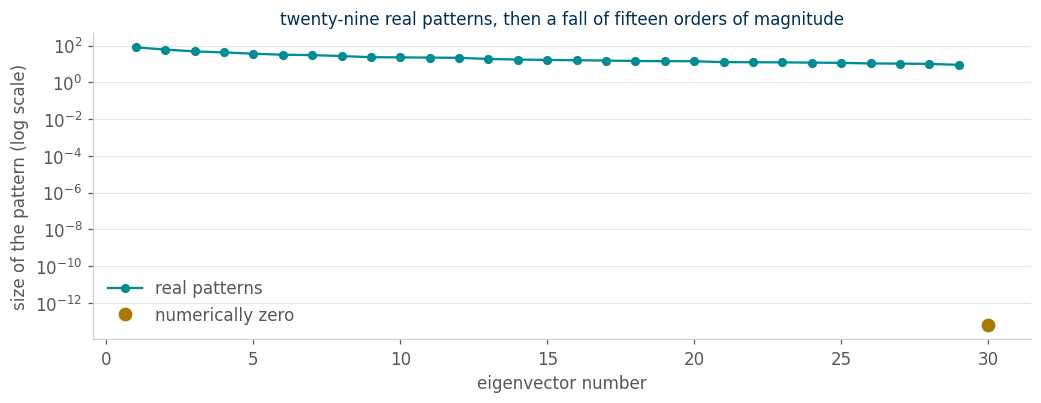

In [12]:
print("rank of A:", np.linalg.matrix_rank(A), f"   ({N} faces, mean removed)")
print("singular values:   #1 %.2f     #29 %.2f     #30 %.3e" % (sv[0], sv[28], sv[29]))
print("ratio #30/#1: %.1e   <- that is zero, not 'small'" % (sv[29] / sv[0]))

fig, ax = plt.subplots(figsize=(9.6, 3.8))
ax.semilogy(range(1, N), np.maximum(sv[:N-1], 1e-16), "o-", color=TEAL, ms=5,
            label="real patterns")
ax.semilogy([N], [max(sv[N-1], 1e-16)], "o", color=GOLD, ms=8, label="numerically zero")
ax.set_xlabel("eigenvector number"); ax.set_ylabel("size of the pattern (log scale)")
ax.set_title(f"twenty-nine real patterns, then a fall of fifteen orders of magnitude",
             fontsize=11)
ax.grid(axis="y"); ax.legend(labelcolor=GREY)
fig.tight_layout(); savefig("spectrum"); plt.show()

### The same 29, drawn geometrically

Two photographs always lie on a line, three on a plane, four in a 3-D slice. Thirty lie in a
29-dimensional one — regardless of how many pixels each photograph has.

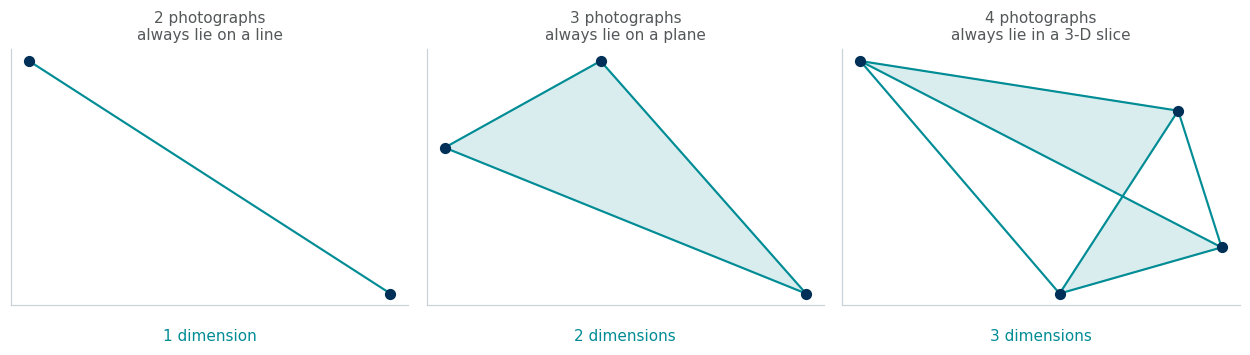

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4))
for ax, k, lab in zip(axes, [2, 3, 4], ["always lie on a line", "always lie on a plane",
                                        "always lie in a 3-D slice"]):
    p = rng.normal(0, 1, (k, 2))
    if k >= 3:
        ax.fill(p[:, 0], p[:, 1], color=TEAL, alpha=.15)
    for i in range(k):
        for j in range(i + 1, k):
            ax.plot(p[[i, j], 0], p[[i, j], 1], color=TEAL, lw=1.4)
    ax.scatter(p[:, 0], p[:, 1], color=NAVY, s=40, zorder=3)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{k} photographs\n{lab}", fontsize=10, color=GREY)
    ax.text(.5, -.14, f"{k-1} dimension{'s' if k > 2 else ''}", transform=ax.transAxes,
            ha="center", color=TEAL, fontsize=10)
fig.tight_layout(); savefig("span"); plt.show()

---
## 9 · Where the information actually sits

The bars fall off a cliff, and that cliff is the whole reason PCA is useful. If the variance
were spread evenly across all 29 components there would be nothing to throw away and no
compression to be had.

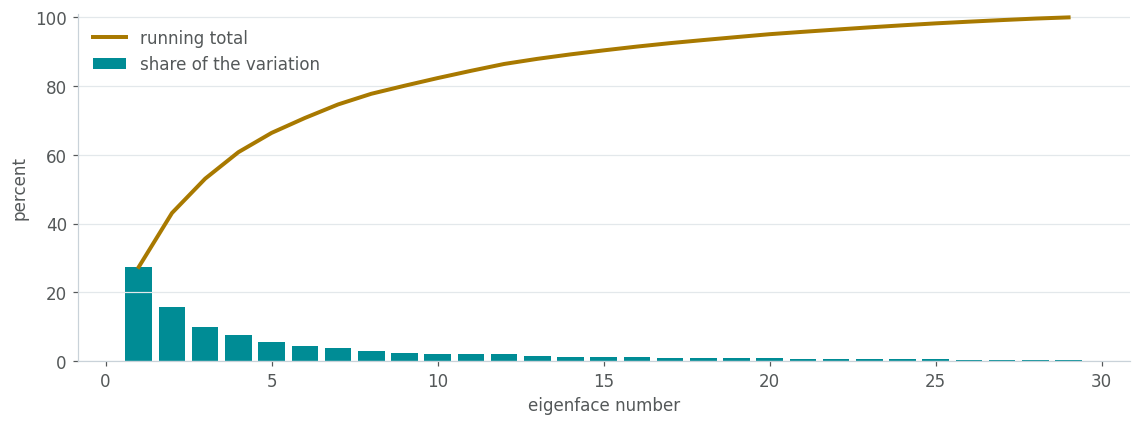

first  1 eigenfaces carry  27.4% of the variation
first  5 eigenfaces carry  66.4% of the variation
first  8 eigenfaces carry  77.8% of the variation
first 15 eigenfaces carry  90.4% of the variation
first 20 eigenfaces carry  95.1% of the variation
first 29 eigenfaces carry 100.0% of the variation


In [14]:
K = len(var_pct) - 1
fig, ax = plt.subplots(figsize=(10.5, 4.0))
ax.bar(range(1, K + 1), var_pct[:K], color=TEAL, label="share of the variation")
ax.plot(range(1, K + 1), cum[:K], color=GOLD, lw=2.6, label="running total")
ax.set_xlabel("eigenface number"); ax.set_ylabel("percent"); ax.set_ylim(0, 101)
ax.grid(axis="y"); ax.legend(labelcolor=GREY)
fig.tight_layout(); savefig("variance"); plt.show()

for k in (1, 5, 8, 15, 20, 29):
    print(f"first {k:>2} eigenfaces carry {cum[k-1]:5.1f}% of the variation")

---
## 10 · The equation: a face is the average plus a weighted sum of patterns

$$\hat{x} \;=\; \mu \;+\; \sum_{i=1}^{k} c_i\,u_i,
\qquad c_i \;=\; u_i^{\mathsf T}\,(x - \mu)$$

The first line is the whole deck. Measure the amounts, then rebuild from them. The eigenfaces
are the alphabet — shared by everyone; the coefficients are the word that spells this
particular person.

Nothing on the left-hand side changes as $k$ grows. The eigenfaces are fixed; only the number
of terms you keep changes.

In [15]:
c = coeffs[TGT]                                  # this face's amounts

def rebuild(i, k):
    """Face i reconstructed from its first k eigenfaces."""
    return mean + coeffs[i, :k] @ comps[:k]

print("the first five amounts for face %02d: %s" % (TGT + 1, np.round(c[:5], 1)))
print()
for k in (1, 2, 4, 8, 15, 29):
    r = rebuild(TGT, k)
    print(f"k = {k:>2}   average pixel {mae(faces[TGT], r):5.2f}% off   "
          f"{cum[k-1]:5.1f}% of the variation captured")

the first five amounts for face 09: [-18.2 -11.   14.8  22.4  -1.7]

k =  1   average pixel 22.47% off    27.4% of the variation captured
k =  2   average pixel 21.65% off    43.1% of the variation captured
k =  4   average pixel 11.68% off    60.8% of the variation captured
k =  8   average pixel  6.12% off    77.8% of the variation captured
k = 15   average pixel  2.66% off    90.4% of the variation captured
k = 29   average pixel  0.00% off   100.0% of the variation captured


### One term at a time

The strongest pattern arrives first, scaled by this face's own amount and added to the average.
Watch what each term buys: exposure and face shape, then the frame of hair, then the person.

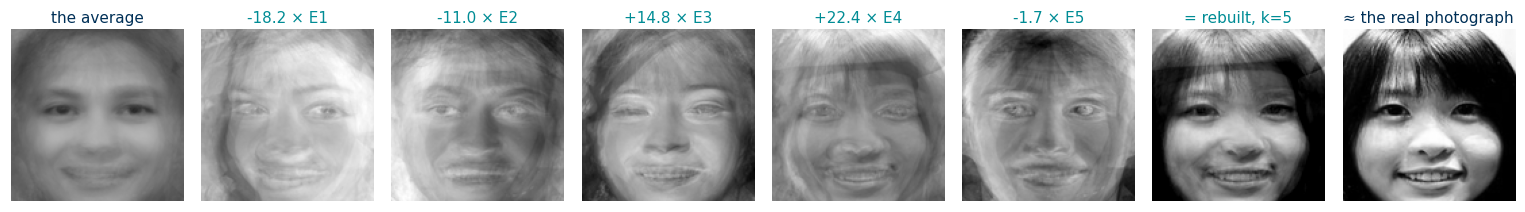

In [16]:
KS = [1, 2, 3, 4, 5]
fig, axes = plt.subplots(1, 2 + len(KS) + 1, figsize=(14, 2.6))
show(mean, axes[0], "the average", tcolor=NAVY)
for j, k in enumerate(KS, start=1):
    show(comps[k-1], axes[j], f"{c[k-1]:+.1f} × E{k}", signed=True, tcolor=TEAL)
show(rebuild(TGT, KS[-1]), axes[-2], f"= rebuilt, k={KS[-1]}", tcolor=TEAL)
show(faces[TGT], axes[-1], "≈ the real photograph", tcolor=NAVY)
fig.tight_layout(); savefig("equation_terms"); plt.show()

### The whole sweep, k = 1 … 29

This is the deck's build-up sequence in one cell. Change `K_SHOW` to step through it slide by
slide in class.

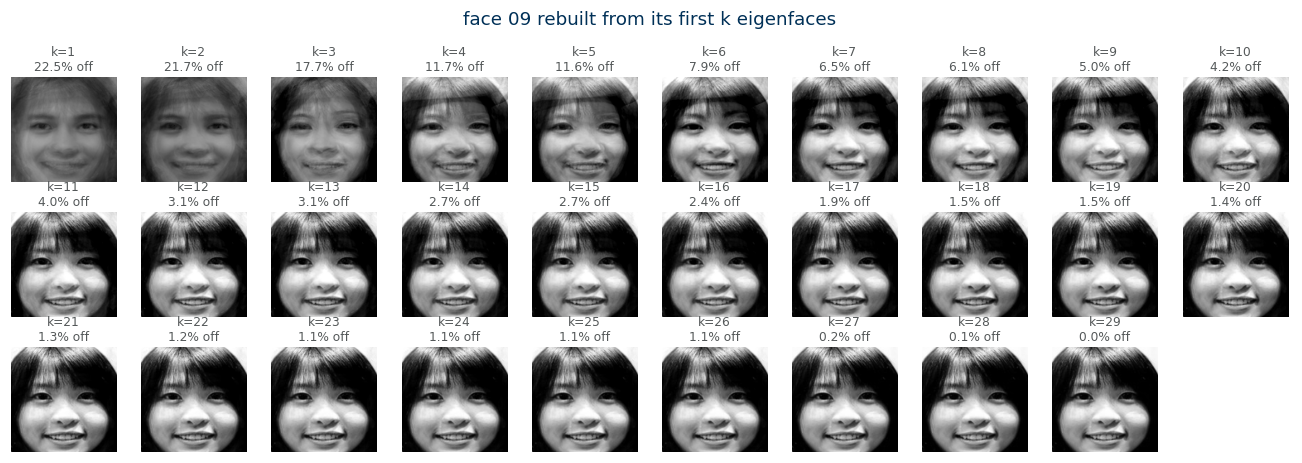

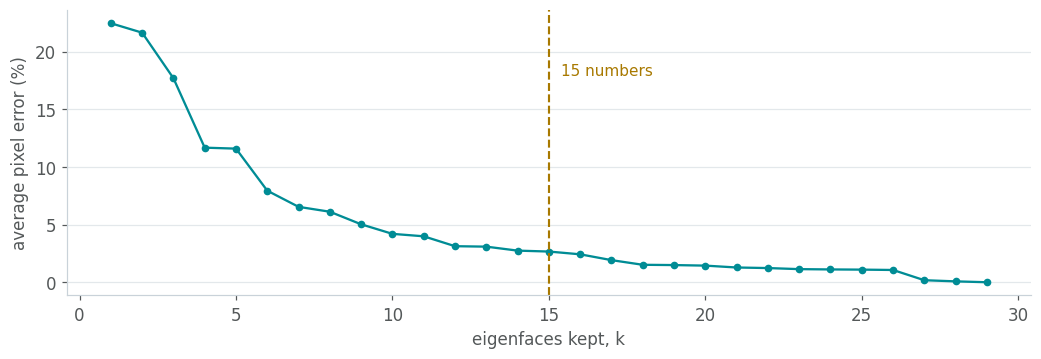

In [17]:
K_SHOW = list(range(1, N))                    # 1 .. 29
recons = np.stack([rebuild(TGT, k) for k in K_SHOW])
errs   = np.array([mae(faces[TGT], r) for r in recons])

grid(recons, [f"k={k}\n{e:.1f}% off" for k, e in zip(K_SHOW, errs)],
     cols=10, w=1.2, fs=8,
     suptitle=f"face {TGT+1:02d} rebuilt from its first k eigenfaces")
savefig("sweep"); plt.show()

fig, ax = plt.subplots(figsize=(9.6, 3.4))
ax.plot(K_SHOW, errs, "o-", color=TEAL, ms=4)
ax.axvline(15, color=GOLD, lw=1.4, ls="--")
ax.text(15.4, errs.max() * .8, "15 numbers", color=GOLD, fontsize=10)
ax.set_xlabel("eigenfaces kept, k"); ax.set_ylabel("average pixel error (%)")
ax.grid(axis="y")
fig.tight_layout(); savefig("error_curve"); plt.show()

### The progression the deck prints

Zero eigenfaces is the average face — the guess you would make knowing nothing at all about
this person. Twenty-nine is exact, because nothing has been discarded.

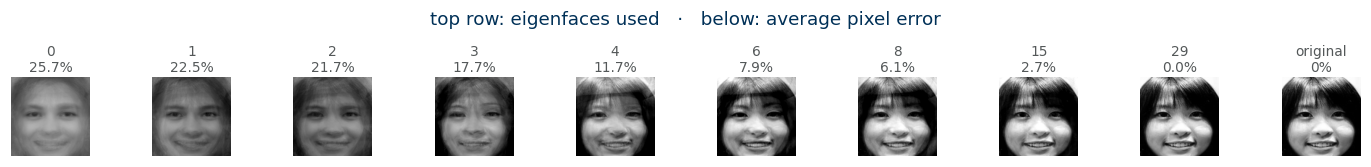

In [18]:
STEPS = [0, 1, 2, 3, 4, 6, 8, 15, 29]
vecs   = [rebuild(TGT, k) for k in STEPS] + [faces[TGT]]
titles = [f"{k}\n{mae(faces[TGT], rebuild(TGT, k)):.1f}%" for k in STEPS] + ["original\n0%"]
grid(vecs, titles, cols=10, w=1.3, fs=9,
     suptitle="top row: eigenfaces used   ·   below: average pixel error")
savefig("progression"); plt.show()

---
## 11 · The results table

The same table that appears on the slides — regenerated, not transcribed.

In [19]:
def err_table(i, label):
    print(f"{label}\n{'after k':>8}  {'avg pixel error':>17}  {'variation captured':>20}")
    print("  " + "-" * 47)
    for k in (1, 2, 4, 6, 8, 15, 20, 29):
        e = mae(faces[i], rebuild(i, k))
        star = "  <-- 15 numbers" if k == 15 else ""
        e_s = "0.00% - exact" if k == N - 1 else f"{e:.2f}%"
        print(f"{k:>8}  {e_s:>17}  {cum[k-1]:>19.1f}%{star}")
    print()

err_table(TGT, f"face {TGT+1:02d}")

face 09
 after k    avg pixel error    variation captured
  -----------------------------------------------
       1             22.47%                 27.4%
       2             21.65%                 43.1%
       4             11.68%                 60.8%
       6              7.94%                 70.7%
       8              6.12%                 77.8%
      15              2.66%                 90.4%  <-- 15 numbers
      20              1.44%                 95.1%
      29      0.00% - exact                100.0%



---
## 12 · The same k, three different people

Every frame below is built from the **same** eigenfaces in the same order; only the amounts
differ. This is the point at which the compression argument becomes concrete: the alphabet is
shared, so you store it once, however many people you have.

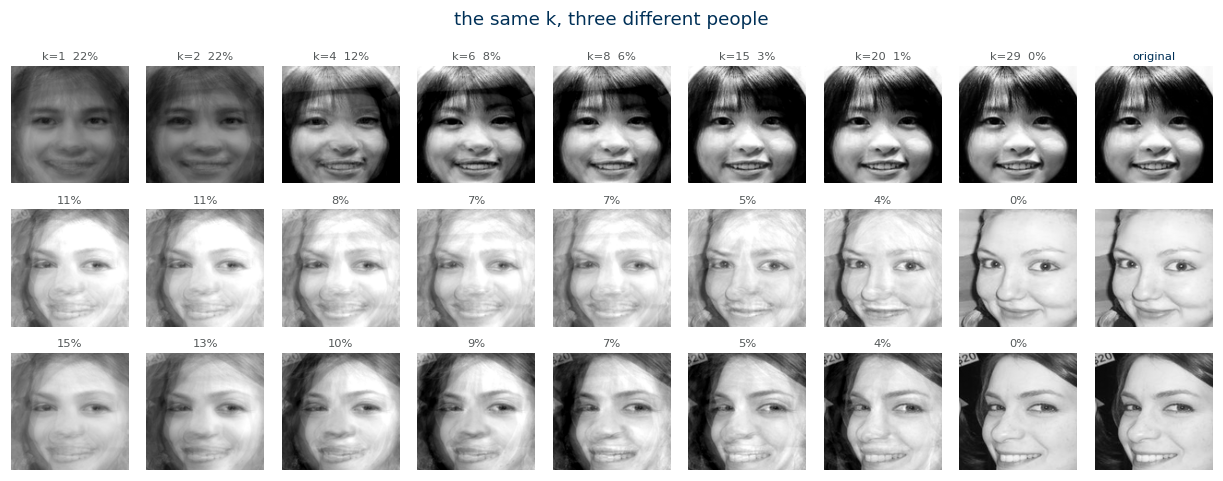

face 09:  k=8 ->  6.12% off,   k=15 ->  2.66% off
face 02:  k=8 ->  7.21% off,   k=15 ->  5.04% off
face 22:  k=8 ->  6.50% off,   k=15 ->  5.17% off


In [20]:
WHO = [TGT, 1, 21]                       # three different faces
KS3 = [1, 2, 4, 6, 8, 15, 20, 29]

fig, axes = plt.subplots(len(WHO), len(KS3) + 1,
                         figsize=(1.25 * (len(KS3) + 1), 1.5 * len(WHO)))
for r, i in enumerate(WHO):
    for cix, k in enumerate(KS3):
        show(rebuild(i, k), axes[r, cix],
             f"k={k}  {mae(faces[i], rebuild(i, k)):.0f}%" if r == 0 else
             f"{mae(faces[i], rebuild(i, k)):.0f}%", fs=7.5)
    show(faces[i], axes[r, -1], "original" if r == 0 else "", tcolor=NAVY, fs=7.5)
fig.suptitle("the same k, three different people", color=NAVY, fontsize=12)
fig.tight_layout(); savefig("compare3"); plt.show()

for i in WHO:
    print(f"face {i+1:02d}:  k=8 -> {mae(faces[i], rebuild(i, 8)):5.2f}% off,"
          f"   k=15 -> {mae(faces[i], rebuild(i, 15)):5.2f}% off")

### Which patterns each person actually needs

The same twenty-nine eigenfaces for everyone. Everything that makes one person not the other is
in the heights of these bars — and a bar chart is a much smaller thing to store than a
photograph.

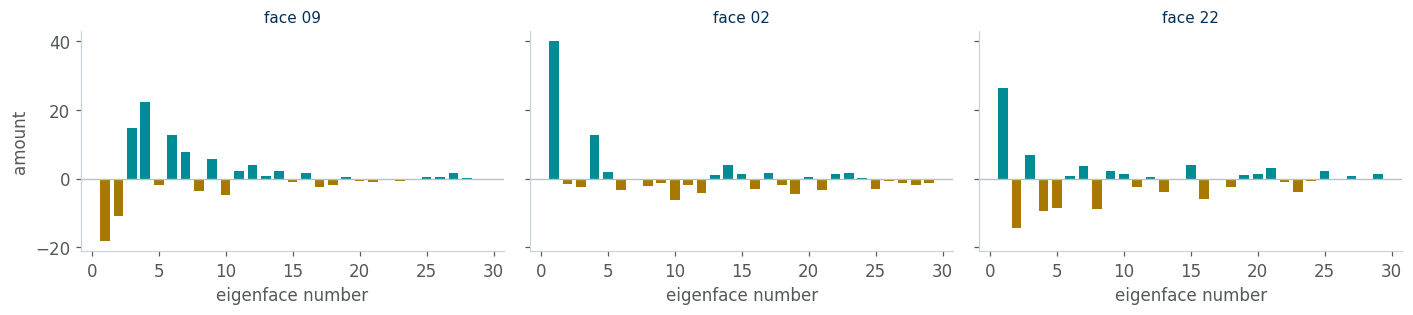

In [21]:
fig, axes = plt.subplots(1, len(WHO), figsize=(13, 3.0), sharey=True)
for ax, i in zip(np.atleast_1d(axes), WHO):
    ci = coeffs[i, :N-1]
    ax.bar(range(1, N), ci, color=[TEAL if v >= 0 else GOLD for v in ci], width=.72)
    ax.axhline(0, color="#B7C0C7", lw=.9)
    ax.set_title(f"face {i+1:02d}", fontsize=10, color=NAVY)
    ax.set_xlabel("eigenface number")
np.atleast_1d(axes)[0].set_ylabel("amount")
fig.tight_layout(); savefig("coef_vector"); plt.show()

---
## 13 · Turning the knobs

Each eigenface is a direction you can walk along. Start at the average face and move
±2 standard deviations along one component at a time. Each row turns one knob — and nobody
told PCA what any of these knobs should mean.

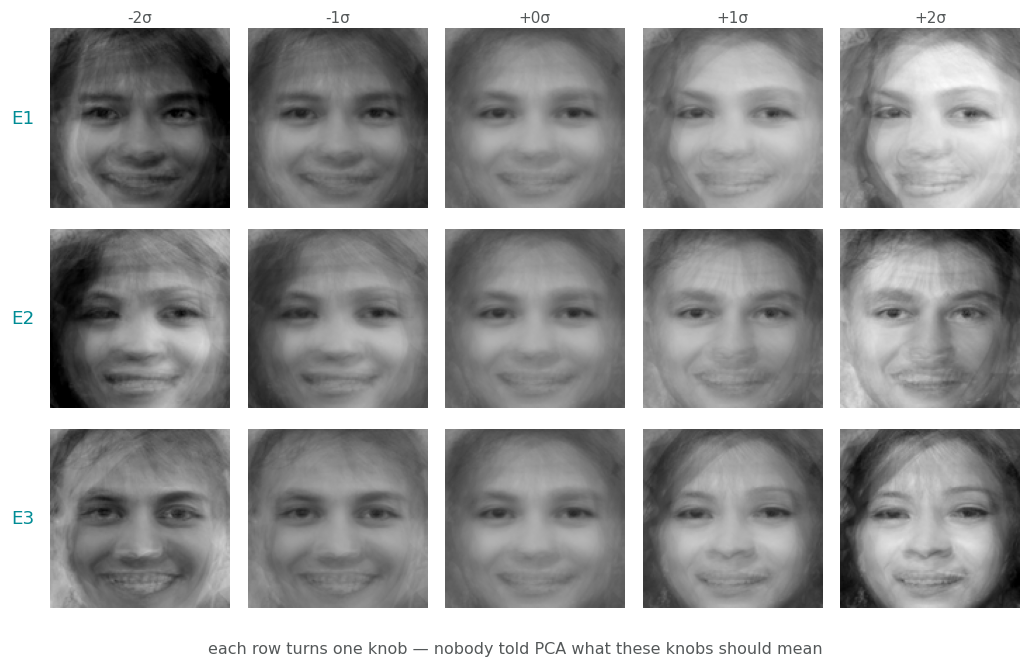

In [22]:
ROWS = 3
fig, axes = plt.subplots(ROWS, 5, figsize=(9.5, 2.05 * ROWS))
for r in range(ROWS):
    for cix, s in enumerate([-2, -1, 0, 1, 2]):
        show(mean + s * sd[r] * comps[r], axes[r, cix],
             f"{s:+d}σ" if r == 0 else None, fs=10)
    axes[r, 0].set_ylabel(f"E{r+1}", color=TEAL, fontsize=12, rotation=0,
                          labelpad=18, va="center")
fig.suptitle("each row turns one knob — nobody told PCA what these knobs should mean",
             color=GREY, fontsize=10.5, y=-0.01)
fig.tight_layout(); savefig("morph"); plt.show()

---
## 14 · Break it: what the model does with things that are not faces

This is the most important cell in the notebook, and the one that maps most directly back to
fault detection.

The model has only ever seen thirty faces. Ask it to rebuild a cat, a car or pure static, and
it does not refuse — it cannot refuse. It returns the closest thing in **face space**, which
comes back looking like a face. The projection error is the only signal that anything was wrong.

That is precisely the SPE statistic from the FDC lecture: the part of the observation the model
could not explain. A detector that tracks only the coefficients (Hotelling's $T^2$) is blind to
this failure, because a cat's coefficients can sit comfortably inside the healthy cloud. You
need the residual as well.

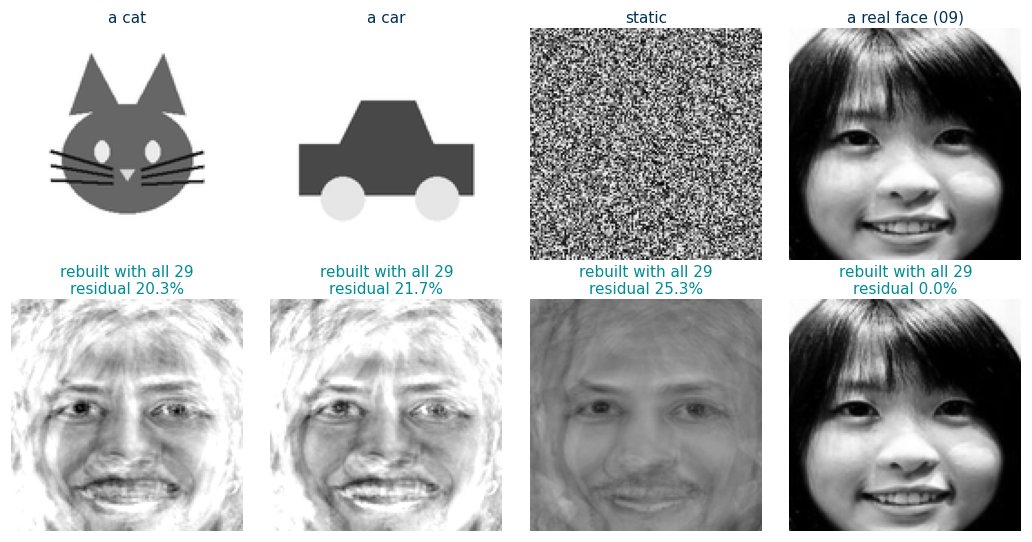

                 input   residual (SPE-like)   distance in coefficient space
  --------------------------------------------------------------------------
                 a cat                20.31%                             7.9
                 a car                21.67%                             8.0
                static                25.30%                             2.5
      a real face (09)                 0.00%                             5.4


In [23]:
def _canvas():
    return Image.new("RGB", (256, 256), (0, 0, 0))

def _fin(im):
    a = np.asarray(im.resize((S, S), Image.LANCZOS).convert("L"), dtype=np.float64) / 255.
    return 1. - a                                  # dark-on-white, like the slides

def draw_cat():
    im = _canvas(); d = ImageDraw.Draw(im); k = 4
    g = lambda v: (int(v*255),) * 3
    d.polygon([(16*k,24*k),(22*k,7*k),(30*k,22*k)], fill=g(.6))
    d.polygon([(48*k,24*k),(42*k,7*k),(34*k,22*k)], fill=g(.6))
    d.ellipse([14*k,21*k,50*k,51*k], fill=g(.6))
    for s in (-1, 1):
        d.ellipse([(32+s*7)*k-2*k,31*k,(32+s*7)*k+2*k,37*k], fill=g(.08))
    d.polygon([(30*k,39*k),(34*k,39*k),(32*k,42*k)], fill=g(.15))
    for i in (-1, 0, 1):
        d.line([(28*k,(41+i*2)*k),(11*k,(38+i*4)*k)], fill=g(.92), width=k)
        d.line([(36*k,(41+i*2)*k),(53*k,(38+i*4)*k)], fill=g(.92), width=k)
    return _fin(im).ravel()

def draw_car():
    im = _canvas(); d = ImageDraw.Draw(im); k = 4
    g = lambda v: (int(v*255),) * 3
    d.rectangle([8*k,32*k,56*k,46*k], fill=g(.72))
    d.polygon([(19*k,32*k),(25*k,20*k),(40*k,20*k),(45*k,32*k)], fill=g(.72))
    for x in (20, 46):
        d.ellipse([(x-6)*k,41*k,(x+6)*k,53*k], fill=g(.10))
    return _fin(im).ravel()


def project(x, k=N-1):
    """Amounts, reconstruction, and the residual the model could not explain."""
    ci = comps[:k] @ (x - mean)
    xh = mean + ci @ comps[:k]
    return ci, xh, x - xh


tests = {"a cat": draw_cat(), "a car": draw_car(), "static": rng.random(D),
         f"a real face ({TGT+1:02d})": faces[TGT]}

fig, axes = plt.subplots(2, len(tests), figsize=(2.4 * len(tests), 5.0))
rows = []
for j, (name, x) in enumerate(tests.items()):
    ci, xh, res = project(x)
    show(x,  axes[0, j], name, tcolor=NAVY)
    show(xh, axes[1, j], f"rebuilt with all {N-1}\nresidual {mae(x, xh):.1f}%", tcolor=TEAL)
    rows.append((name, mae(x, xh), float(np.sqrt((ci ** 2 / np.maximum(evals[:N-1], 1e-12)).sum()))))
fig.tight_layout(); savefig("breakit"); plt.show()

print(f"{'input':>22}  {'residual (SPE-like)':>20}  {'distance in coefficient space':>30}")
print("  " + "-" * 74)
for name, e, t2 in rows:
    print(f"{name:>22}  {e:>19.2f}%  {t2:>30.1f}")

Read that table the way you would read an FDC alarm — and read the two columns against each
other, because they disagree, which is the whole lesson.

The real face has a residual of exactly zero. That is not a triumph; it is bookkeeping. It is
one of the thirty faces the model was fitted on, and 29 components reproduce 30 mean-centred
faces perfectly by construction. Exercise 3 measures this honestly on a held-out face.

The cat and the car have large residuals even though the model tried its hardest. **The residual
is what catches a fault of a kind you never trained on** — nothing about "cat" was anticipated
when the model was built.

Now look at static, which is the case worth a full minute in class. It has the **largest**
residual of the three and the **smallest** coefficient distance — smaller even than a real
face's. Random noise is very nearly perpendicular to the 29-dimensional face subspace, so
almost none of it lands on any eigenface: measured only by its coefficients, pure static looks
like the most ordinary thing in the room.

A detector watching Hotelling's $T^2$ alone would wave it through. That is exactly why the FDC
lecture carries two statistics and not one: $T^2$ asks *is this an unusual amount of a familiar
pattern?*, SPE asks *is this built out of familiar patterns at all?* Faults exist that only one
of them can see, and here is one you can look at.

---
## 15 · The error you are left with is exactly the eigenvalues you threw away

$$\big\langle \lVert x - \hat{x} \rVert^2 \big\rangle
\;=\; \lambda_{k+1} + \lambda_{k+2} + \cdots + \lambda_{N-1}$$

Averaged over the training set, the squared reconstruction error equals the sum of the
discarded eigenvalues — which is why the variance chart doubles as an error budget, and why no
other $k$-dimensional flat subspace does better. PCA is provably the best *linear* choice, not
merely a reasonable one.

The cell below checks the identity numerically. Agreement to machine precision is the point.

In [24]:
print(f"{'k':>4}  {'measured mean sq. error':>24}  {'sum of discarded lambda':>24}  {'ratio':>8}")
print("  " + "-" * 68)
for k in (1, 2, 4, 8, 15, 20, 28):
    R = np.stack([rebuild(i, k) for i in range(N)])
    measured  = ((faces - R) ** 2).sum(1).mean()     # averaged over the N training faces
    predicted = evals[k:].sum()                      # = sum of the discarded eigenvalues
    print(f"{k:>4}  {measured:>24.6f}  {predicted:>24.6f}  {measured/predicted:>8.4f}")

   k   measured mean sq. error   sum of discarded lambda     ratio
  --------------------------------------------------------------------
   1                567.257460                567.257460    1.0000
   2                444.643982                444.643982    1.0000
   4                306.372247                306.372247    1.0000
   8                173.701776                173.701776    1.0000
  15                 74.973548                 74.973548    1.0000
  20                 38.189301                 38.189301    1.0000
  28                  2.699849                  2.699849    1.0000


---
## 16 · The compression, counted honestly

Fifteen numbers per person instead of 16,384 is a thousand-fold saving — but only if you are
honest about the fixed cost. The fifteen eigenfaces and the mean face have to be stored too.
They are stored **once**, however many people you have, which is why the saving improves as
the population grows and why this was a workable face-recognition system on 1990s hardware.

In [25]:
KEEP = 15
per_person_raw  = D
per_person_pca  = KEEP
fixed_cost      = (KEEP + 1) * D                    # eigenfaces + the mean face

print(f"raw:  {N} x {D:,} = {N*D:,} numbers")
print(f"pca:  {N} x {KEEP} + {KEEP+1} x {D:,} = {N*KEEP + fixed_cost:,} numbers")
print(f"      -> {(N*D) / (N*KEEP + fixed_cost):.1f}x smaller for {N} people\n")
for pop in (30, 100, 1_000, 100_000):
    raw = pop * D
    pca = pop * KEEP + fixed_cost
    print(f"{pop:>8,} people:  {raw/pca:8.1f}x smaller"
          f"   (per person: {per_person_raw:,} -> {per_person_pca})")

print(f"\naverage error at k={KEEP}, over all {N} faces: "
      f"{np.mean([mae(faces[i], rebuild(i, KEEP)) for i in range(N)]):.2f}%")

raw:  30 x 16,384 = 491,520 numbers
pca:  30 x 15 + 16 x 16,384 = 262,594 numbers
      -> 1.9x smaller for 30 people

      30 people:       1.9x smaller   (per person: 16,384 -> 15)
     100 people:       6.2x smaller   (per person: 16,384 -> 15)
   1,000 people:      59.1x smaller   (per person: 16,384 -> 15)
 100,000 people:     929.8x smaller   (per person: 16,384 -> 15)

average error at k=15, over all 30 faces: 5.06%


---
## 17 · Every number that appears on a slide

One dictionary, regenerated from the run above. Compare it against the deck: if you have
swapped the faces, this is the list of things that changed.

In [26]:
stats = {
    "source": SOURCE,
    "n_faces": int(N),
    "pixels_per_face": int(D),
    "rank": int(np.linalg.matrix_rank(A)),
    "var_pct": [round(float(v), 2) for v in var_pct[:N-1]],
    "cumulative": [round(float(v), 2) for v in cum[:N-1]],
    "singular_values": {"first": round(float(sv[0]), 2),
                        "29th": round(float(sv[N-2]), 2),
                        "30th": f"{sv[N-1]:.2e}"},
    "target_face": int(TGT + 1),
    "target_coeffs_first5": [round(float(v), 1) for v in coeffs[TGT, :5]],
    "mae_by_k": {int(k): round(float(mae(faces[TGT], rebuild(TGT, k))), 1)
                 for k in range(1, N)},
    "captured_by_k": {int(k): round(float(cum[k-1]), 1) for k in range(1, N)},
}

for k in ("source", "n_faces", "pixels_per_face", "rank", "singular_values",
          "target_face", "target_coeffs_first5"):
    print(f"{k:>22}: {stats[k]}")
print(f"{'variance, first 8':>22}: {stats['var_pct'][:8]}")
print(f"{'captured at k=8,15':>22}: {stats['captured_by_k'][8]}%, {stats['captured_by_k'][15]}%")
print(f"{'error at k=8,15':>22}: {stats['mae_by_k'][8]}%, {stats['mae_by_k'][15]}%")

with open("stats_notebook.json", "w") as f:
    json.dump(stats, f, indent=1)
print("\nwritten to stats_notebook.json")

                source: Flickr-Faces-HQ (FFHQ), NVIDIA (bundled)
               n_faces: 30
       pixels_per_face: 16384
                  rank: 29
       singular_values: {'first': 80.17, '29th': 9.0, '30th': '6.10e-14'}
           target_face: 9
  target_coeffs_first5: [-18.2, -11.0, 14.8, 22.4, -1.7]
     variance, first 8: [27.42, 15.69, 9.99, 7.7, 5.61, 4.33, 3.94, 3.1]
    captured at k=8,15: 77.8%, 90.4%
       error at k=8,15: 6.1%, 2.7%

written to stats_notebook.json


---
## 18 · Exercises

These are the point. Each one breaks something, and what breaks tells you what PCA was
actually relying on.

---

**1 · Alignment is not a detail.**
Shift each face by a random 0–12 pixels horizontally before running the PCA, then look at E1–E4
and at the variance chart. How many components does the model now spend describing *position*
rather than people? Relate your answer to why the FDC lecture aligns traces before fitting a
baseline.

**2 · How many faces do you actually need?**
Rerun with N = 5, 10, 20, 30 and plot the k = 15 reconstruction error of a **held-out** face
against N. Does the error keep falling? What is the rank in each case, and what does that tell
you about the largest useful k?

**3 · Held-out is not the same as training.**
Every error in this notebook is measured on faces the model was fitted on. Refit on 25 faces,
then reconstruct the 5 you left out. Compare the error curves. Which k would you have chosen
from the training curve, and which from the held-out one?

**4 · Break the residual detector.**
Construct an input that is *not* a face but has a **small** residual. (Hint: build one out of
eigenfaces on purpose.) What does this tell you about relying on reconstruction error alone as
a novelty detector — and what would the FDC lecture's $T^2$ statistic say about your input?

**5 · Both statistics, drawn.**
For all 30 faces plus the cat, the car and static, compute $T^2$ (scaled distance in
coefficient space) and SPE (residual), and plot them against each other on log axes. Draw the
two thresholds. Which region catches which kind of anomaly? This is the $T^2$-versus-SPE plot
from the FDC lecture, on data you can see.

**6 · Colour, and the cost of pretending.**
Load the portraits in RGB and treat each as a vector of 3 × 16,384 numbers. Does the rank
change? Do the eigenfaces change qualitatively? Now run PCA on each channel separately and
compare — what assumption does the joint version make that the separate one does not?

**7 · Not faces at all.**
Point the same code at 30 process traces, 30 spectrograms, or 30 handwritten digits. Nothing in
the maths cares. Where does the method work well, and where does it fail — and can you predict
which from the spectrum alone, before looking at any reconstruction?

---

### If you take three things away

1. **Data has a grain.** Measurements that look independent usually are not. PCA finds the few
   directions along which things really vary, and the rest is nearly empty.
2. **A face is a short list.** Mean face plus about fifteen amounts. The patterns are shared;
   only the amounts are yours.
3. **It only knows what it saw.** Thirty faces buy you 29 knobs, and anything that is not a face
   comes back as one. Always check the residual, not just the coefficients.